# Assignment 7: Linear Model Selection and Regularization

Dataset(s) needed:
Kaggle House Prices (https://www.kaggle.com/c/house-prices-advanced-regression-techniques/data)

## Learning Objectives
- Produce a model with l2 regularization, with a statistically significant improvement over a model without regularization.
- Produce a model with l1 regularization, with a ...
- Produce a model with both l1 and l2 regularization terms, with a ...
- Produce a logistic regression model with a statistically significant improvement over the null model (a model without input variables).
- Produce a generalized additive model with a statistically significant improvement over the null model (a model without input variables).

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

data = pd.read_csv('House+Prices.csv')
data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


 Question 1.1: Drop the Id column as it is not needed for prediction

In [2]:
data = data.drop(columns="Id")

 Question 1.2: Visualize a scatter plot of 'GrLivArea' in the x-axis and 'SalePrice' in the y-axis. Can you spot any outliers?

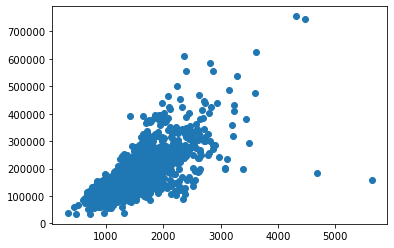

In [3]:
import matplotlib.pyplot as plt
plt.scatter(data["GrLivArea"], data["SalePrice"])
plt.show()

 Question 1.3: Removing outliers in the data for all GrLivArea greater than 4000 then check the scatter plot again

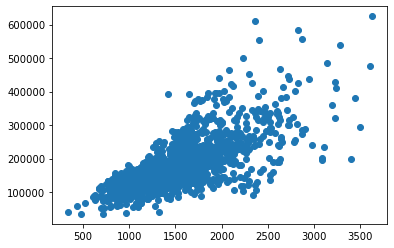

In [4]:
# Removing outliers for GrLivArea < 4000
data = data[data['GrLivArea']<4000]
#To Do Create a scatter plot
plt.scatter(data["GrLivArea"], data["SalePrice"])
plt.show()

Quesiont 2.1: Convert categorical variable into dummy variables using pandas get_dummies API


In [5]:
len(data.columns.tolist())

80

In [6]:
data = pd.get_dummies(data)

In [7]:
len(data.columns.tolist())

288

In [8]:
data.head(10)

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,60,65.0,8450,7,5,2003,2003,196.0,706,0,...,0,0,0,1,0,0,0,0,1,0
1,20,80.0,9600,6,8,1976,1976,0.0,978,0,...,0,0,0,1,0,0,0,0,1,0
2,60,68.0,11250,7,5,2001,2002,162.0,486,0,...,0,0,0,1,0,0,0,0,1,0
3,70,60.0,9550,7,5,1915,1970,0.0,216,0,...,0,0,0,1,1,0,0,0,0,0
4,60,84.0,14260,8,5,2000,2000,350.0,655,0,...,0,0,0,1,0,0,0,0,1,0
5,50,85.0,14115,5,5,1993,1995,0.0,732,0,...,0,0,0,1,0,0,0,0,1,0
6,20,75.0,10084,8,5,2004,2005,186.0,1369,0,...,0,0,0,1,0,0,0,0,1,0
7,60,NaN,10382,7,6,1973,1973,240.0,859,32,...,0,0,0,1,0,0,0,0,1,0
8,50,51.0,6120,7,5,1931,1950,0.0,0,0,...,0,0,0,1,1,0,0,0,0,0
9,190,50.0,7420,5,6,1939,1950,0.0,851,0,...,0,0,0,1,0,0,0,0,1,0


Question 2.2: Impute missing data by the median of each column.

In [9]:
sum(data.isna().sum())

348

In [10]:
for column in data.columns.tolist(): data[column]=data[column].fillna(value=data[column].mean())

Question 2.2b: Make sure that there are no null values remaining

In [11]:
if sum(data.isna().sum()) == 0: print("There are no null values remaining")

There are no null values remaining


Question 2.3: Generate train test split 70/30. Set random_state=42

In [12]:
X, y = data.drop(columns="SalePrice"), data["SalePrice"]

In [13]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

Question 3.1: Train a linear regression algorithm to predict `SalePrice` from the remaining features.

In [14]:
from sklearn.linear_model import Ridge, RidgeCV, ElasticNet, LassoCV, LassoLarsCV, LinearRegression, ElasticNetCV
from sklearn.metrics import mean_squared_error

#Fit a linear regression model to this data
lr = LinearRegression().fit(X_train, y_train)

Question 3.2: Evaluate the model and report the performance on both training and test data. These numbers will serve as our benchmark performance.

In [15]:
#Compute the RMSE
y_pred = lr.predict(X_train)
rmse_train_lr = mean_squared_error(y_train,y_pred, squared=False)
print("Training Data:",rmse_train_lr)
y_pred = lr.predict(X_test)
rmse_test_lr = mean_squared_error(y_test,y_pred, squared=False)
print("Testing Data:",rmse_test_lr)

Training Data: 18137.55425497929
Testing Data: 23657.367373415458


We now train a regularized version of `LinearRegression` called `LassoCV` (you can load it from the same library). `Lasso` has an argument called `alpha`, which is the **shrinkage parameter** we referred to earlier.

Question 4.1: Let `alpha = 0.000001` and train a `Lasso` algorithm. Show that the resulting model is practically identical to the one we trained with `LinearRegression`. There are different ways to show this, so you will need to think of a way. <span style="color:red" float:right>[2 point]</span>

In [16]:
from sklearn import linear_model
from warnings import filterwarnings
from sklearn.exceptions import ConvergenceWarning #After completing the assignment I decided to include this line to supress the warnings.
filterwarnings("ignore", category=ConvergenceWarning)
#Fitting the lasso model to this data
ls = linear_model.Lasso(alpha=0.000001).fit(X_train,y_train)
#ls = LassoCV(alpha=0.000001,max_iter=10000).fit(X_train,y_train)
#Compute the RMSE 
y_pred = ls.predict(X_train)
rmse_train_ls = mean_squared_error(y_train,y_pred, squared=False)
print("Difference in RMSE for Training Data between models:",rmse_train_ls-rmse_train_lr)
y_pred = ls.predict(X_test)
rmse_test_ls = mean_squared_error(y_test,y_pred, squared=False)
print("Difference in RMSE for Testing Data between models:",rmse_test_ls-rmse_test_lr)

Difference in RMSE for Training Data between models: 0.0077812188101233914
Difference in RMSE for Testing Data between models: 180.90057359476123


In [17]:
sum(lr.coef_-ls.coef_)

-258871.96111065525

In [18]:
sum(lr.coef_-ls.coef_)/len(lr.coef_-ls.coef_)

-901.9928958559416

In [19]:
np.median(lr.coef_-ls.coef_)

-1.080461411489523

In [20]:
#insert a visual that shows that lasso and lr are identical for both testing set and training set

Question 4.2: Iteratively train a new `Lasso` model, letting `alpha` change each time to one of the values given by `alpha_vals` below, keeping track of the performance on the training and test data each time, and storing the model's coefficients each time (the `coef_` attribute of the trained model)

In [21]:
alpha_vals = np.arange(0.01, 5, .01) # values of alpha we want to iterate over
ls_train_score = []
ls_train_coef_ = []
for alpha in alpha_vals:
    ls = linear_model.Lasso(alpha=alpha, max_iter=2500).fit(X_train,y_train)
    ls_train_score.append(ls.score(X_train,y_train))
    ls_train_coef_.append(ls.coef_)
ls_test_score = []
ls_test_coef_ = []
for alpha in alpha_vals:
    ls = linear_model.Lasso(alpha=alpha, max_iter=2500).fit(X_train,y_train)
    ls_test_score.append(ls.score(X_test,y_test))
    ls_test_coef_.append(ls.coef_)  

In [22]:
pd.DataFrame({'linreg': lr.coef_, 'lasso': ls.coef_}).head(10)

,linreg,lasso
0,-58.959672,-60.710708
1,53.488995,53.549175
2,0.898588,0.844115
3,5617.845762,5625.383299
4,5365.615865,5263.082788
5,301.234770,302.947213
6,114.081765,112.826827
7,28.545395,28.419487
8,17.564635,31.090515
9,7.389343,21.987295


Question 4.3: Using a visual, show how the performance on the training and test data changed as we gradually increased `alpha`.

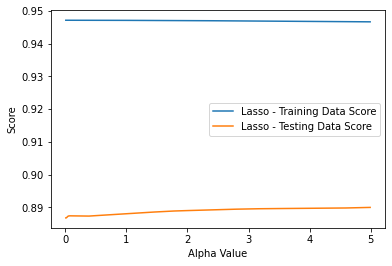

In [23]:
plt.plot(alpha_vals, ls_train_score, label="Lasso - Training Data Score")
plt.plot(alpha_vals, ls_test_score, label="Lasso - Testing Data Score")
plt.xlabel("Alpha Value")
plt.ylabel("Score")
plt.legend()
plt.show()

Question 4.4: Using a visual, show how the model's coefficients changed as we gradually increased the shrinkage parameter `alpha`. HINT: They should appear to be shrinking toward zero as you increase `alpha`!

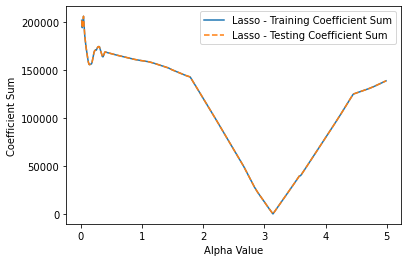

In [24]:
plt.plot(alpha_vals, [abs(sum(c)) for c in ls_train_coef_], label="Lasso - Training Coefficient Sum")
plt.plot(alpha_vals, [abs(sum(c)) for c in ls_test_coef_ ], label="Lasso - Testing Coefficient Sum", linestyle="--")
plt.xlabel("Alpha Value")
plt.ylabel("Coefficient Sum")
plt.legend()
plt.show()

Question 5.1: Repeat steps in Question 4 this time using `Ridge` instead of `Lasso`. We will use the following range for `alpha`: <span style="color:red" float:right>[2 point]

In [25]:
alpha_vals = np.arange(0.1, 200, 1)

In [26]:
ri_train_score = []
ri_train_coef_ = []
for alpha in alpha_vals:
    ri = linear_model.Ridge(alpha=alpha).fit(X_train,y_train)
    ri_train_score.append(ri.score(X_train,y_train))
    ri_train_coef_.append(ri.coef_)
ri_test_score = []
ri_test_coef_ = []
for alpha in alpha_vals:
    ri = linear_model.Ridge(alpha=alpha).fit(X_train,y_train)
    ri_test_score.append(ri.score(X_test,y_test))
    ri_test_coef_.append(ri.coef_)

In [27]:
pd.DataFrame({'lasso': ls.coef_, 'ridge': ri.coef_}).head(10)

,lasso,ridge
0,-60.710708,-121.306526
1,53.549175,60.660140
2,0.844115,0.455653
3,5625.383299,9357.097359
4,5263.082788,5318.152321
5,302.947213,336.667779
6,112.826827,118.667211
7,28.419487,39.969821
8,31.090515,21.518211
9,21.987295,5.498375


Question 5.2: Using a visual, show how the performance on the training and test data changed as we gradually increased `alpha`.

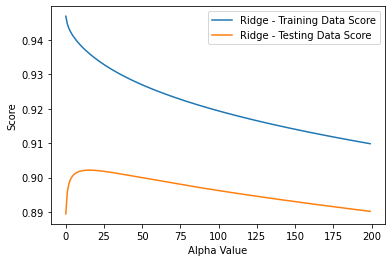

In [28]:
plt.plot(alpha_vals, ri_train_score, label="Ridge - Training Data Score")
plt.plot(alpha_vals, ri_test_score, label="Ridge - Testing Data Score")
plt.xlabel("Alpha Value")
plt.ylabel("Score")
plt.legend()
plt.show()

Question 5.3: Using a visual, show how the model's coefficients changed as we gradually increased the shrinkage parameter `alpha`.

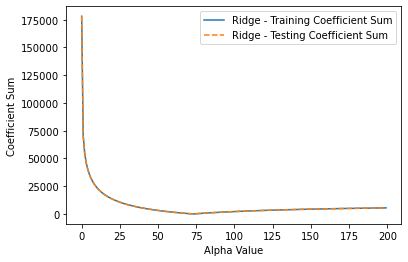

In [29]:
plt.plot(alpha_vals, [abs(sum(c)) for c in ri_train_coef_ ], label="Ridge - Training Coefficient Sum")
plt.plot(alpha_vals,  [abs(sum(c)) for c in ri_test_coef_ ], label="Ridge - Testing Coefficient Sum", linestyle="--")
plt.xlabel("Alpha Value")
plt.ylabel("Coefficient Sum")
plt.legend()
plt.show()

Question 6: Repeat questions 5.1 - 5.3 using elasticnet experimenting with differnet values of alpha

In [30]:
el_train_score = []
el_train_coef_ = []
for alpha in alpha_vals:
    el = linear_model.ElasticNet(alpha=alpha).fit(X_train,y_train)
    el_train_score.append(el.score(X_train,y_train))
    el_train_coef_.append(el.coef_)
el_test_score = []
el_test_coef_ = []
for alpha in alpha_vals:
    el = linear_model.ElasticNet(alpha=alpha).fit(X_train,y_train)
    el_test_score.append(el.score(X_test,y_test))
    el_test_coef_.append(el.coef_) 

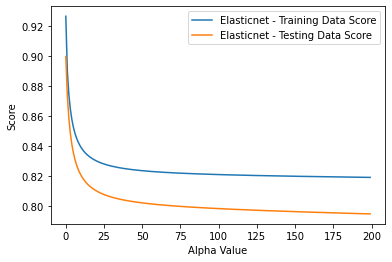

In [31]:
plt.plot(alpha_vals, el_train_score, label="Elasticnet - Training Data Score")
plt.plot(alpha_vals, el_test_score, label="Elasticnet - Testing Data Score")
plt.xlabel("Alpha Value")
plt.ylabel("Score")
plt.legend()
plt.show()

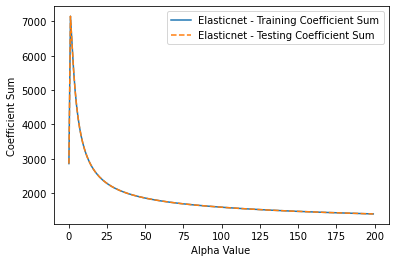

In [32]:
plt.plot(alpha_vals, [abs(sum(c)) for c in el_train_coef_ ], label="Elasticnet - Training Coefficient Sum")
plt.plot(alpha_vals,  [abs(sum(c)) for c in el_test_coef_ ], label="Elasticnet - Testing Coefficient Sum", linestyle="--")
plt.xlabel("Alpha Value")
plt.ylabel("Coefficient Sum")
plt.legend()
plt.show()

Question 7: Based on the results, briefly describe the effect of changing `alpha` on the coefficients of both `Ridge`, `Lasso`, anf `ElasticNet`. What value of `alpha` would you choose for each case? You do not need to give a precise answer, but choose a number.

#### In the case of the Lasso model I would choose a value around $\alpha$ = 3 but then again, the behavior in the coefficient sum for $\alpha$ between zero and five was unexpected in that it decreased until around $\alpha$ = 3 and after which the sum increased. In the case of the Ridge model it was much more clear that the optimal choice for $\alpha$ should be around 10 since that's the neighborhood of the maximum score for the testing data and it corresponds to the point in which the sum of coefficients begins to plateu towards an apparent horizontal asymptote (further strengthening this choice for $\alpha$). When it comes to the Elasticnet model I found the results to be much more confusing that that for Ridge; I found that there didn't appear to be an optimal value for alpha other than one that's as close to 0 as possible, this felt rather strange after analyzing the performance of the Ridge model which very clearly prefers a nonzero value for $\alpha$. 

Question 8: Create a new text cell in your Notebook: Complete a 50-100 word summary (or short description of your thinking in applying this week's learning to the solution) of your experience in this assignment. Include:

What was your incoming experience with this model, if any? what steps you took, what obstacles you encountered. how you link this exercise to real-world, machine learning problem-solving. (What steps were missing? What else do you need to learn?) This summary allows your instructor to know how you are doing and allot points for your effort in thinking and planning, and making connections to real-world work

#### Again, what's unfortunate is I didn't have any incoming experience with any of these models, I did run into some issues when calling them but beyond that I had relatively no issues completing this assignment. Compared to last week, the models on this dataset ran fairly quickly which I'm glad about, I did however run into one issue, persistent convergence warnings. I found that for the Lasso model especially I was having convergence errors no matter how much I increased `n_iter` variable for the model, I realized after sometime that it was unavoidable and the most I could do was supress the warnings since it wasn't a critical error. The fact it never converged to me just signifys the optimal coefficients haven't been found by the model, not that the model is useless or "incorrect". I could see how this process of exploring similar models to obtian marginal performance increases would be done in relatively every field where ML is applied, if the amount of time and effort spent searching for a better model is less expensive relative to the monetary increases that would result from such an improvement than this is more than a fruitful effort. I apologize for being unable to give a real-world example however, this is due to my lack of experience in the field and in applying ML.